In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


pd.reset_option("display.float_format")

# Extract applicable columns from datasets and save them

In [2]:
path = "/Users/qianj/Library/Mobile Documents/com~apple~CloudDocs/AA_2024-2026 job/Erdos_Project/MedicarePhysicianAndOtherPractitioners-byProvider"

In [7]:
col_keep = ['Rndrng_NPI',
            'Rndrng_Prvdr_Ent_Cd',
            'Rndrng_Prvdr_State_Abrvtn',
            'Rndrng_Prvdr_Type',
            'Rndrng_Prvdr_Mdcr_Prtcptg_Ind',
            'Tot_HCPCS_Cds',
            'Tot_Benes',
            'Tot_Srvcs',
            'Tot_Sbmtd_Chrg',
            'Tot_Mdcr_Alowd_Amt',
            'Tot_Mdcr_Pymt_Amt',
            'Tot_Mdcr_Stdzd_Amt',
            'Drug_Sprsn_Ind',
            'Drug_Tot_HCPCS_Cds',
            'Drug_Tot_Benes',
            'Drug_Tot_Srvcs',
            'Drug_Sbmtd_Chrg',
            'Drug_Mdcr_Alowd_Amt',
            'Drug_Mdcr_Pymt_Amt',
            'Drug_Mdcr_Stdzd_Amt',
            'Med_Sprsn_Ind',
            'Drug_Tot_HCPCS_Cds',
            'Med_Tot_Benes',
            'Med_Tot_Srvcs',
            'Med_Sbmtd_Chrg',
            'Med_Mdcr_Alowd_Amt',
            'Med_Mdcr_Pymt_Amt',
            'Med_Mdcr_Stdzd_Amt',
            'Bene_Avg_Age',
            'Bene_Avg_Risk_Scre'] # excluding many detailed columns

In [8]:
def extract_columns_and_save(year):
    df = pd.read_csv(f'{path}/MUP_PHY_R25_V20_D{str(year)[-2:]}_Prov.csv')
    df[col_keep].to_csv(f'{path}/PROV_{year}.csv',index=False)
    return

In [9]:
for year in range(2013,2024):
    extract_columns_and_save(year)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/qianj/Library/Mobile Documents/com~apple~CloudDocs/AA_2024-2026 job/Erdos_Project/MedicarePhysician&OtherPractitioners-byProvider/MUP_PHY_R25_V20_D13_Prov.csv'

In [13]:
import zipfile
from pathlib import Path

path = '/Users/qianj/Library/Mobile Documents/com~apple~CloudDocs/AA_2024-2026 job/Erdos_Project/'

zip_path = f"{path}/datasets.zip"

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for year in range(2013,2024):
        f = Path(f'{path}/MedicarePhysicianAndOtherPractitioners-byProvider/PROV_{year}.csv')
        z.write(f, arcname=f.name)   # arcname controls name inside zip

print("Wrote:", zip_path)


Wrote: /Users/qianj/Library/Mobile Documents/com~apple~CloudDocs/AA_2024-2026 job/Erdos_Project//datasets.zip


# Explore data

In [3]:
df13 = pd.read_csv(f'{path}/PROV_2013.csv')

In [4]:
# check on the Medicare Participation Indicator 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind' column

df13['Rndrng_Prvdr_Mdcr_Prtcptg_Ind'].describe(include='all')

count     956251
unique         2
top            Y
freq      955295
Name: Rndrng_Prvdr_Mdcr_Prtcptg_Ind, dtype: object

In [5]:
df13['Rndrng_Prvdr_Mdcr_Prtcptg_Ind'].value_counts()

Rndrng_Prvdr_Mdcr_Prtcptg_Ind
Y    955295
N       956
Name: count, dtype: int64

# further inspect the 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind'=N rows

In [6]:
# check their payment totals

mask = df13['Rndrng_Prvdr_Mdcr_Prtcptg_Ind']=='N'
df13_Non_Prt = df13[mask]
print('total submitted charge amount = ', f"{sum(df13_Non_Prt['Tot_Sbmtd_Chrg']):,.2f}")
print('total Medicare payment amount = ', f"{sum(df13_Non_Prt['Tot_Mdcr_Pymt_Amt']):,.2f}")
print('total Medicare Standardized payment amount = ', f"{sum(df13_Non_Prt['Tot_Mdcr_Stdzd_Amt']):,.2f}")

total submitted charge amount =  11,895,561.97
total Medicare payment amount =  7,212,406.39
total Medicare Standardized payment amount =  8,040,452.20


## Q1: maybe we should discard the standarized payment amount since it counts geographical adjustment, which is a factor we will take into consideration in our analysis. YES.

In [7]:
# check payment/charge ratio for participation = Y vs N

mask = df13['Rndrng_Prvdr_Mdcr_Prtcptg_Ind']=='N'
df13_Non_Prt = df13[mask]
df13_Prt = df13[~mask]
print('payment/charge ratio for Y = ', sum(df13_Prt['Tot_Mdcr_Pymt_Amt'])/sum(df13_Prt['Tot_Sbmtd_Chrg']))
print('payment/charge ratio for N = ', sum(df13_Non_Prt['Tot_Mdcr_Pymt_Amt'])/sum(df13_Non_Prt['Tot_Sbmtd_Chrg']))
print('payment/charge ratio for ALL = ', sum(df13['Tot_Mdcr_Pymt_Amt'])/sum(df13['Tot_Sbmtd_Chrg']))

payment/charge ratio for Y =  0.28136226822679206
payment/charge ratio for N =  0.6063106903389113
payment/charge ratio for ALL =  0.2813744603538035


## Q2: should we ignore the Medicare Participation Indicator (Rndrng_Prvdr_Mdcr_Prtcptg_Ind)? No: because the payment/charge rate is much higher for non participants.

In [8]:
# check the percentage of providers in different practice area

mask = df13['Rndrng_Prvdr_Mdcr_Prtcptg_Ind']=='N'
df13_Non_Prt = df13[mask]
df13_Prt = df13[~mask]

def percentage_of_providers(df):
    df_type = df.groupby('Rndrng_Prvdr_Type').agg(
        Tot_Num = ('Rndrng_Prvdr_Type','size'),
        Tot_Srvcs = ('Tot_Srvcs','sum'),
        Tot_Sbmtd_Chrg = ('Tot_Sbmtd_Chrg','sum'),
        Tot_Mdcr_Pymt_Amt = ('Tot_Mdcr_Pymt_Amt','sum')
    ).sort_values('Tot_Mdcr_Pymt_Amt',ascending=False)
    percentage = (df_type['Tot_Num']/df.shape[0]).sort_values(ascending=False)
    percentage = percentage[percentage > 0]
    return percentage, df_type

print('provider type percentage for non participants = \n', percentage_of_providers(df13_Non_Prt)[0][:5])
print('provider type percentage for participants = \n', percentage_of_providers(df13_Prt)[0][:5])

provider type percentage for non participants = 
 Rndrng_Prvdr_Type
Chiropractic                            0.785565
Psychiatry                              0.053347
Optometry                               0.036611
Multispecialty Clinic/Group Practice    0.031381
Physical Therapist                      0.020921
Name: Tot_Num, dtype: float64
provider type percentage for participants = 
 Rndrng_Prvdr_Type
Internal Medicine      0.100122
Family Practice        0.084979
Nurse Practitioner     0.067721
Physician Assistant    0.052470
Emergency Medicine     0.041122
Name: Tot_Num, dtype: float64


In [9]:
percentage_of_providers(df13_Non_Prt)[1]

,Tot_Num,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Pymt_Amt
Rndrng_Prvdr_Type,,,,
Chiropractic,751,221805.4,7936465.58,4902741.85
Physical Therapist,20,30723.0,981004.28,623873.61
Psychiatry,51,14150.0,1203179.68,596279.99
Internal Medicine,9,3192.0,322134.27,217410.25
Multispecialty Clinic/Group Practice,30,3573.0,309666.79,196784.54
Obstetrics/Gynecology,12,1703.0,195167.54,121292.98
Optometry,35,2485.0,167270.92,103685.84
Diagnostic Radiology,1,702.0,134825.35,102686.07
Otolaryngology,1,767.0,88173.53,60183.09


In [10]:
percentage_of_providers(df13_Prt)[1]

,Tot_Num,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Pymt_Amt
Rndrng_Prvdr_Type,,,,
Internal Medicine,95646,214317672.0,2.362149e+10,9.140317e+09
Ophthalmology,17549,57688455.7,1.708291e+10,6.171710e+09
Cardiology,22783,89389143.5,1.783245e+10,4.988691e+09
Ambulance Service Supplier,9751,160551766.4,1.470528e+10,4.919719e+09
Family Practice,81180,138051739.5,1.214877e+10,4.765233e+09
...,...,...,...,...
Addiction Medicine,110,131851.0,1.447915e+07,5.514170e+06
Mammographic Screening Center,19,44184.0,7.748988e+06,2.851572e+06
Unknown Supplier/Provider,52,26217.0,9.240380e+06,2.642189e+06


## Q3: Why is there non integer total service number?

In [11]:
# check all the service number with non integer rows

mask = df13['Tot_Srvcs'].apply(float.is_integer)
df13[~mask]

,Rndrng_NPI,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_Type,Rndrng_Prvdr_Mdcr_Prtcptg_Ind,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,...,Med_Sprsn_Ind,Drug_Tot_HCPCS_Cds.1,Med_Tot_Benes,Med_Tot_Srvcs,Med_Sbmtd_Chrg,Med_Mdcr_Alowd_Amt,Med_Mdcr_Pymt_Amt,Med_Mdcr_Stdzd_Amt,Bene_Avg_Age,Bene_Avg_Risk_Scre
80,1003006180,O,NV,Ambulance Service Supplier,Y,8,8167,94896.8,14337276.69,6203937.48,...,NaN,0.0,8167.0,94896.8,14337276.69,6203937.48,4817379.63,5338018.57,68,2.1790
255,1003013780,O,NJ,Ambulance Service Supplier,Y,3,237,59679.9,3352574.90,2065571.15,...,NaN,0.0,237.0,59679.9,3352574.90,2065571.15,1643939.93,1854626.11,75,5.4128
285,1003015355,O,IL,Ambulance Service Supplier,Y,3,36,918.3,29283.00,24088.70,...,NaN,0.0,36.0,918.3,29283.00,24088.70,19092.80,16475.20,75,1.6004
373,1003019704,O,WI,Ambulance Service Supplier,Y,2,51,981.6,49418.63,31727.59,...,NaN,0.0,51.0,981.6,49418.63,31727.59,25102.34,26726.38,79,1.7709
420,1003023276,I,VA,Orthopedic Surgery,Y,110,334,1932.5,417846.00,119747.32,...,NaN,2.0,334.0,1073.0,391107.00,110981.88,84193.30,91141.62,72,1.1611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955338,1992939706,O,NJ,Ambulance Service Supplier,Y,3,84,37695.8,3683448.00,2017678.97,...,NaN,0.0,84.0,37695.8,3683448.00,2017678.97,1606996.14,1935016.24,69,7.5097
955587,1992958342,O,TX,Ambulance Service Supplier,Y,5,58,1632.4,88230.40,38908.44,...,NaN,0.0,58.0,1632.4,88230.40,38908.44,30697.45,31016.25,75,2.1722
955884,1992973499,O,FL,Ambulance Service Supplier,Y,6,465,27014.5,669252.00,618207.70,...,NaN,0.0,465.0,27014.5,669252.00,618207.70,490124.42,424027.76,76,1.9768
956043,1992985733,O,CA,Ambulance Service Supplier,Y,6,2189,70470.9,9833259.70,3513318.12,...,NaN,0.0,2189.0,70470.9,9833259.70,3513318.12,2762594.50,3315869.73,78,3.7025


## Q4: Should we predict spending per service? per PROVIDER? total spending? If we predict spending per service, we need to predict the number of service as well. If total spending, in what sense?

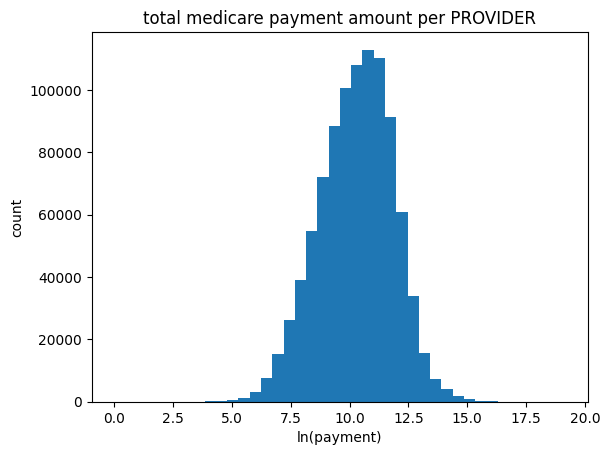

In [12]:
# histogram for total_medicare_payment_amount
M_payment = df13['Tot_Mdcr_Pymt_Amt'].apply(lambda x: x if x!=0 else 1) # turn all 0 payments to 1 so it won't be negative infinite after taking log

plt.hist(np.log(M_payment),bins=40)
plt.title('total medicare payment amount per PROVIDER')
plt.xlabel('ln(payment)')
plt.ylabel('count')
plt.show()

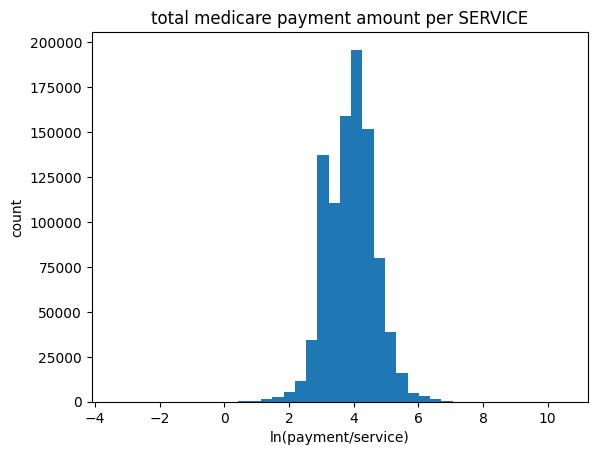

In [13]:
# histogram for medicare_payment per service
Num_service = df13['Tot_Srvcs'].apply(lambda x: x if x!=0 else 1) # turn all 0 service to 1 so we won'r devide by zero
M_payment = df13['Tot_Mdcr_Pymt_Amt'].apply(lambda x: x if x!=0 else 1) # turn all 0 payments to 1 so it won't be negative infinite after taking log

plt.hist(np.log(M_payment/Num_service),bins=40)
plt.title('total medicare payment amount per SERVICE')
plt.xlabel('ln(payment/service)')
plt.ylabel('count')
plt.show()

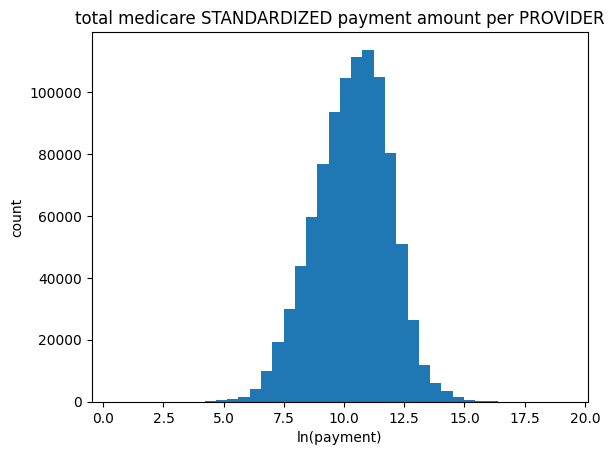

In [14]:
# histogram for total_medicare_standardized_payment_amount
M_payment = df13['Tot_Mdcr_Stdzd_Amt'].apply(lambda x: x if x!=0 else 1) # turn all 0 payments to 1 so it won't be negative infinite after taking log

plt.hist(np.log(M_payment),bins=40)
plt.title('total medicare STANDARDIZED payment amount per PROVIDER')
plt.xlabel('ln(payment)')
plt.ylabel('count')
plt.show()

## The total_medical_payment histogram has a better bell shaped curve

# Load all datasets

In [53]:
provider_types = pd.DataFrame({'Rndrng_Prvdr_Type':[]})
number_types = {}

for year in range(2023,2012,-1):
    df = pd.read_csv(f'{path}/PROV_{year}.csv')
    number_types[f'{year}']=df['Rndrng_Prvdr_Type'].nunique()
    df_type = df.groupby('Rndrng_Prvdr_Type').size().rename(f'{year}_num').reset_index(drop=False)
    provider_types = pd.merge(df_type,provider_types,on='Rndrng_Prvdr_Type',how='outer')

print(number_types)
provider_types

{'2023': 104, '2022': 103, '2021': 103, '2020': 102, '2019': 99, '2018': 99, '2017': 95, '2016': 91, '2015': 91, '2014': 91, '2013': 90}


,Rndrng_Prvdr_Type,2013_num,2014_num,2015_num,2016_num,2017_num,2018_num,2019_num,2020_num,2021_num,2022_num,2023_num
0,Addiction Medicine,110.0,125.0,156.0,168.0,204.0,216.0,230.0,226.0,246.0,250.0,257.0
1,Adult Congenital Heart Disease,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,45.0,48.0,50.0
2,Advanced Heart Failure and Transplant Cardiology,NaN,NaN,NaN,NaN,25.0,479.0,563.0,649.0,713.0,752.0,791.0
3,All Other Suppliers,607.0,666.0,714.0,797.0,834.0,94.0,91.0,73.0,62.0,59.0,54.0
4,Allergy/ Immunology,NaN,NaN,NaN,3377.0,3392.0,3371.0,3385.0,3328.0,3296.0,3300.0,3270.0
...,...,...,...,...,...,...,...,...,...,...,...,...
127,Unknown Physician Specialty Code,82.0,113.0,286.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128,Unknown Supplier/Provider,52.0,27.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
129,Unknown Supplier/Provider Specialty,NaN,NaN,NaN,12.0,7.0,7.0,11.0,12.0,13.0,19.0,23.0
130,Urology,8978.0,8981.0,8986.0,9015.0,9055.0,9098.0,9180.0,9142.0,9173.0,9217.0,9330.0


In [54]:
provider_types.to_csv(f'{path}/Number_Provider_by_type_10_years.csv')

In [30]:
provider_types = provider_types.fillna(0)
provider_types

,Rndrng_Prvdr_Type,2013_num,2014_num,2015_num,2016_num,2017_num,2018_num,2019_num,2020_num,2021_num,2022_num,2023_num
0,Addiction Medicine,110.0,125.0,156.0,168.0,204.0,216.0,230.0,226.0,246.0,250.0,257.0
1,Adult Congenital Heart Disease,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,45.0,48.0,50.0
2,Advanced Heart Failure and Transplant Cardiology,0.0,0.0,0.0,0.0,25.0,479.0,563.0,649.0,713.0,752.0,791.0
3,All Other Suppliers,607.0,666.0,714.0,797.0,834.0,94.0,91.0,73.0,62.0,59.0,54.0
4,Allergy/ Immunology,0.0,0.0,0.0,3377.0,3392.0,3371.0,3385.0,3328.0,3296.0,3300.0,3270.0
...,...,...,...,...,...,...,...,...,...,...,...,...
127,Unknown Physician Specialty Code,82.0,113.0,286.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
128,Unknown Supplier/Provider,52.0,27.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
129,Unknown Supplier/Provider Specialty,0.0,0.0,0.0,12.0,7.0,7.0,11.0,12.0,13.0,19.0,23.0
130,Urology,8978.0,8981.0,8986.0,9015.0,9055.0,9098.0,9180.0,9142.0,9173.0,9217.0,9330.0


In [31]:
provider_types.to_csv(f'{path}/Number_Provider_by_type_10_years.csv',index=False)

In [ ]:
provider_types = provider_types.set_index('Rndrng_Prvdr_Type')

In [43]:
cols = provider_types.columns.tolist()

In [52]:
provider_types['mean'] = provider_types[cols].mean(axis=1)
provider_types['std'] = provider_types[cols].std(ddof=1,axis=1)
provider_types['coef_of_var'] = provider_types['std']/provider_types['mean']
provider_types.sort_values('coef_of_var',ascending=False).to_csv(f'{path}/Number_Provider_by_type_10_years.csv')

## Q5: Should we go through each provider_type and group similar categories together?